In [56]:
#Library imports
import matplotlib.pyplot as plt
import pandas as pd

#Datasets imports
#Old datasets
all_space_mission_launches = pd.read_csv("original/all_space_mission_launches.csv")
TMDB_movie_dataset_v11 = pd.read_csv("original/TMDB_movie_dataset_v11.csv")
top_movies_original = pd.read_csv("original/box_office/top_movies_cleaned_data.csv")

#Re-worked datasets
space_missions = pd.read_csv("re_worked/final/space_mission_dataset.csv")
movies = pd.read_csv("re_worked/movies_dataset.csv")
box_office = pd.read_csv("re_worked/weekend_box_office.csv")

**Title**

**Introduction**
* Set the stage - new era for NASA with the Artemis missions (great scope, lunar landing and base);First media attention was in 2019 and Artemis I generating great media coverage in 2022; Project Hail Mary (scifi) movie was a massive success; Dune series is also a success -> got me thinking about the cultural impact of such space events and their effect on the cultural zeitgeist as a whole. In today's day and age films are one of the most widely spread and enjoyed forms of entertainment, and have often reflectioned the times' popular culture, opinions, fears and hopes. 

Brief overview of - 1. major space events; 2. cultural importance of Sci-Fi cinema. Some discussion on how they have been tied, leading to the research questions and hypotheses.

* Hypothesis:
Idea - I want to see whether there is a connection between major space events, the movies being made and audience's interest in them. For the purposes of this project, a space event is defined as a major space‑related commercial milestones like those during the Cold War space race, the launch of the international space station, the recent Artemis II NASA mission and others.

The connections I will be examining for:

1. Do space events increase the number of Sci-Fi movies that are made? - Because movie production is dependent on many different factors, I will search for a connection within 2-3 years after the event.
   
2. Do space events increase audience's interest in Sci-Fi movies? - Here, I will examine the first weekend box office revenue as I believe it represents the most clean indicator of the public's interest in a project as opinions have't yet been formed, there aren't many reviews of the films, word of mouth hasn't set in. The metric is not perfect however as things like the director, cast, marketing affect the publics willingness and want to see the movie.

So, H0 is "the number of space launch missions has an effect on the number of scifi movies and the audience's interest in them/ H1 is "the number of space launch missions has no effect on the number of scifi movies and the audience's interest in them".


**Literature Review/ Discussion on the topic - Give it a title**
Discussion on whether and how events from the real world have influenced the movie industry and audience; same about scifi movies



**Data and Methodology**

**Dataset Description**

For this analysis, I used three publicly available datasets from kaggle.com.

The first one, originally called all_space_mission_launches, contained inforamtion on both the successful and unsuccessful space mission launches from 1957 until early 2024. Information regarding this dataset, before it was altered, can be seen below:

In [33]:
#Overview of the original all_space_mission_launches dataset
print(f"Rows x columns dimensions: {all_space_mission_launches.shape}\n")
print(f"Column names:\n {all_space_mission_launches.columns}\n")
print(f"Each columns data type:\n {all_space_mission_launches.dtypes}\n")
print(f"Missing values per column:\n {all_space_mission_launches.isna().sum()}\n")
print("Organisation (categorical data) - shows which organisation executed the missions.\n"
    "Location (categorical data) - shows launch site names and location.\n"
    "Datetime (categorical data) - shows the date and time of launches.\n"
    "Details (categorical data) - shows information on the rocket and mission names.\n"
    "Rocket Status (categorical data) - shows if the rocket, used in the mission, is either 'Active' or 'Retired'.\n"
    "Price (numerical data) - shows the cost of each mission.\n"
    'Mission Status (categorical data) - shows whether the mission was a success or not.'
)

Rows x columns dimensions: (6711, 8)

Column names:
 Index(['Unnamed: 0', 'Organisation', 'Location', 'Datetime', 'Details',
       'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

Each columns data type:
 Unnamed: 0          int64
Organisation       object
Location           object
Datetime           object
Details            object
Rocket_Status      object
Price             float64
Mission_Status     object
dtype: object

Missing values per column:
 Unnamed: 0           0
Organisation         0
Location             0
Datetime             0
Details              0
Rocket_Status        0
Price             4074
Mission_Status       0
dtype: int64

Organisation (categorical data) - shows which organisation executed the missions.
Location (categorical data) - shows launch site names and location.
Datetime (categorical data) - shows the date and time of launches.
Details (categorical data) - shows information on the rocket and mission names.
Rocket Status (categorical da

In [39]:
#Overview of the modified space_missions dataset
print(f"Rows x columns dimensions: {space_missions.shape}\n")
print(f"Column names:\n {space_missions.columns}\n")
print(f"Each columns data type:\n {space_missions.dtypes}\n")
print(f"Missing values per column:\n {space_missions.isna().sum()}\n")

Rows x columns dimensions: (6656, 3)

Column names:
 Index(['organisation', 'launch_location', 'date'], dtype='object')

Each columns data type:
 organisation       object
launch_location    object
date               object
dtype: object

Missing values per column:
 organisation       0
launch_location    0
date               0
dtype: int64



When cleaning it, the first thing I did was to delete the "Unnamed: 0" column, as it served no purpose. I then created a new column called "date" and kept only the date data from 'datetime' in the form of day/month/year. I also noticed that the information in the original column was incomplete for 2024. Because of that I decided not to include them and stick to the timeframe of 01.01.1960 - 31.12.2013. After cleaning the dates, I renamed the "country" column to "launch_location" and re-wrote the rows to only include the name of the country, ocean/ sea or genral place that rockets were launched from. These two changes brought some more uniformaty to the dataset and made working with it easier. The "Details", "Rocket_Status", "Price" and "Mission_Status" columns were deleted, as they could not serve this analysis in any meaningful way. Finally, the column titles were standartized and re-written with a snake_case convention and renamed to space_mission_dataset.

The second dataset was originaly called - TMDB_movie_dataset_v11 and included information for over 1 million movies. Information on it's first iteration can be seen below:

In [15]:
#Overview of the original TMDB_movie_dataset_v11 dataset

print(f"Rows x columns dimensions:\n {TMDB_movie_dataset_v11.shape}\n")
print(f"Column names: {TMDB_movie_dataset_v11.columns}\n")
print(f"Each columns data type:\n {TMDB_movie_dataset_v11.dtypes}\n")
print(f"Missing values per column:\n {TMDB_movie_dataset_v11.isna().sum()}\n")

Rows x columns dimensions:
 (1402844, 24)

Column names: Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

Each columns data type:
 id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
backdrop_path            object
budget                    int64
homepage                 object
imdb_id                  object
original_language        object
original_title           object
overview                 object
popular

Because the original columns were 24 in number, going through each and every one would hamper this report. To avoid this, I shall focus on the main adjustments that I made and will leave a summary of the re-worked dataset below this paragraph. The first modification tackeled the problem with duplicates in the "id", "imdb_id" and "title" columns. I removed rows where all three duplicate fields matched (retaining their first instance), then repeated the process on every pair combination. This left me with only generic title repeats (e.g., Home, Mother), I deleted the only true duplicate remaining manually. The other major change I made was related to the "status" and "release_date" columns. I removed the films before 1960, along with rows with no information in "release_date" or "genres". Also, after finding conflicting data between "status" and "release_date", I decided to avoid speculation in my analysis as much as possible and deleted rows where films had any other status than "Released". Finally, in the "production_countries" column, United States of America was changed to US and United Kingdom to UK, so as to be like the space mission dataset.

In [19]:
#Overview of the modified TMDB_movie_dataset_v11, now movies_dataset
print(f"Rows x columns dimensions:\n {movies.shape}\n")
print(f"Column names:\n {movies.columns}\n")
print(f"Each columns data type:\n {movies.dtypes}\n")
print(f"Missing values per column:\n {movies.isna().sum()}\n")

Rows x columns dimensions:
 (388688, 10)

Column names:
 Index(['id', 'title', 'status', 'release_date', 'original_language',
       'original_title', 'overview', 'genres', 'production_countries',
       'keywords'],
      dtype='object')

Each columns data type:
 id                       int64
title                   object
status                  object
release_date            object
original_language       object
original_title          object
overview                object
genres                  object
production_countries    object
keywords                object
dtype: object

Missing values per column:
 id                           0
title                        0
status                       0
release_date                 0
original_language            0
original_title               0
overview                 42566
genres                       0
production_countries     77631
keywords                228363
dtype: int64



The final dataset that was used, was called Top Movies (Cleaned Data) and it had a plethora or information - 32 columns of it. From them, I left only 11 and ended up using only three in my analysis - genre, release_date and opening_weekend_usd. I made sure that there were no empty rows for these columns and converted the column titles to snake_case. As this dataset was already cleaned, the work I did mostly served the purpose of double-checking it.

In [32]:
#Overview of the original Top Movies (Cleaned Data) dataset
print(f"Rows x columns dimensions: {top_movies_original.shape}\n")
print(f"Column names:\n {top_movies_original.columns}\n")
print(f"Each columns data type:\n {top_movies_original.dtypes}\n")
print(f"Missing values per column:\n {top_movies_original.isna().sum()}\n")

Rows x columns dimensions: (6569, 32)

Column names:
 Index(['id', 'Movie Name', 'Release Date', 'Production Budget (USD)',
       'Domestic Gross (USD)', 'Worldwide Gross (USD)',
       'Domestic Box Office (USD)', 'International Box Office (USD)',
       'Worldwide Box Office (USD)', 'Est. Domestic DVD Sales (USD)',
       'Est. Domestic Blu-ray Sales (USD)',
       'Total Est. Domestic Video Sales (USD)', 'Opening Weekend (USD)',
       'Legs', 'Infl. Adj. Dom. BO (USD)', 'Video Release', 'MPAA Rating',
       'Running Time (minutes)', 'Franchise', 'Keywords', 'Source', 'Genre',
       'Production Method', 'Creative Type', 'Production/Financing Companies',
       'Production Countries', 'Languages', 'Domestic Releases',
       'International Releases', 'Theater counts', 'Domestic Share Percentage',
       'Movie URL'],
      dtype='object')

Each columns data type:
 id                                         int64
Movie Name                                object
Release Date        

In [38]:
#Overview of the modified box_office dataset
print(f"Rows x columns dimensions: {box_office.shape}\n")
print(f"Column names:\n {box_office.columns}\n")
print(f"Each columns data type:\n {box_office.dtypes}\n")
print(f"Missing values per column:\n {box_office.isna().sum()}\n")

Rows x columns dimensions: (5272, 9)

Column names:
 Index(['id', 'movie_name', 'release_date', 'worldwide_gross_usd',
       'international_box_office_usd', 'worldwide_box_office_usd',
       'opening_weekend_usd', 'keywords', 'genre'],
      dtype='object')

Each columns data type:
 id                                int64
movie_name                       object
release_date                     object
worldwide_gross_usd               int64
international_box_office_usd    float64
worldwide_box_office_usd        float64
opening_weekend_usd               int64
keywords                         object
genre                            object
dtype: object

Missing values per column:
 id                                0
movie_name                        0
release_date                      0
worldwide_gross_usd               0
international_box_office_usd    793
worldwide_box_office_usd        793
opening_weekend_usd               0
keywords                        299
genre                  

**Analytical Approach**

Firstly, I will examine the re-worked movie and spce_missions dataset seperately, visualize them and interpret what I see. The purpose behind this is to understand them better and to look for any interesting behaviour that may appear. Afterwards I will juxtapose them toghether and compare annual counts of missions with annual counts of science fiction films and test whether film production leads, lags, or coincides with mission activity. I shall then perform a correlation analysis between mission years and the original plus lagged sci‑fi series. This will indicate whether some correlation exists between the two. Following this, I will also juxtapose the first weekend box office earnings for Sci-Fi films against the number of space mission to test my second question - do space events increase audience's interest in Sci-Fi movies. I have chosen to view first weekend box office earnings as a measure of audience interets, as it bypasses some of the biases and provides a somewhat clean indicator of demand - before reviews and word of mouth. The box office/space mission visual shall be accompanied by another correlation analysis of a time-lag series.

**Limitations**

Before moving forward, it would be beneficial to discuss some of the limitations, with which this paper is faced. Firstly, there could always be more data. While the datasets are not necessarily small, more information would always help crystalize the findings and see the bigger picture more clearly. Secondly, not all columns in the sets are used - some were left on purpose as I thought that the data they contained could be useful or could provide an interesting perspective. Sadly, they remained idle - some are due to time constraints and others due to a lack of any meaningful ideas on how to best implement them in my analysis. Another limitation is that missions are treated as a continous count and no special analysis is done around major, historical events like the Apollo 11 mission, the Mars rover landings and SpaceX's milestones, among others.Finaly, while using first weekend box office metric does eliminate some of the biase it is unable to circumvent all of it. Factors such as the director, cast and marketing all influence audience's decision whether or not to see a film. Still, while not perfect, the box office metrics are able to show the initial want and willigness to see a film. 

**Results and Discussion**

**General Analysis**

At a first glance, the below visuals show two different stories. The missions graph clearly shows the momentum gained during the "Space Race" and subsequent period of slow decline, ending in a platou around the middle of the 2000s. Launch output gradualy began to climb back up after that, skyrocketing after 2020. On the other hand, sci-fi films have been experiencing a slow, decades long incrase, seemingly unaffected by space exploration initiatives. There are some similarities that could be seen - the general increase during the 60's, some of the spikes in movie releases following a period of higher mission launches (period between 1980 - 1985) and subsequent stagnation after periods of low luanches (around the begining of the 2000s). Overall, no clear pattern can be seen from just these two graphs.

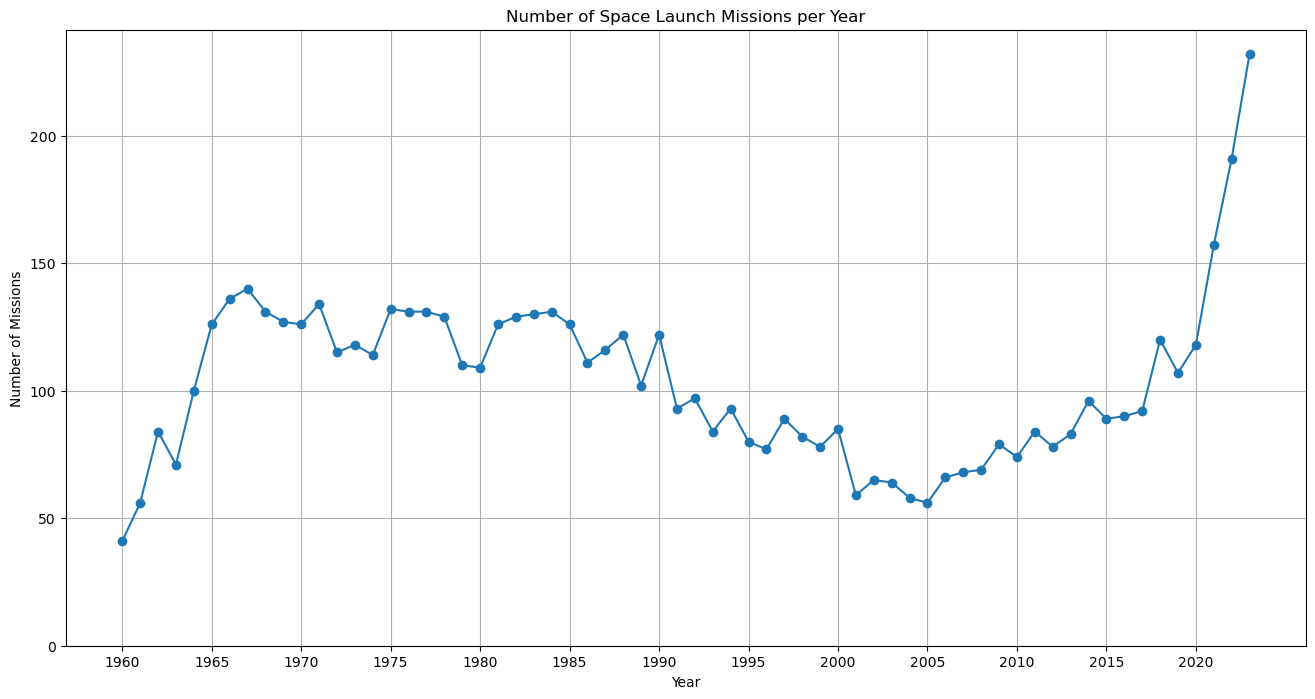

In [50]:
#Creating a number of launches per year visual

#Converting the set's date column to datetime
space_missions['date'] = pd.to_datetime(space_missions['date'], format = "%d/%m/%Y")

#Converting into a datetime format
space_missions['date'] = pd.to_datetime(space_missions['date'], errors='coerce')


#Creating an extra column with just the year, so I can group by it
space_missions['year'] = space_missions['date'].dt.year

#Counting the missions per year and grouping them
missions_per_year = space_missions.groupby('year').size()

#Visualizing the number of space missions per year
plt.figure(figsize = (16,8))
plt.plot(missions_per_year.index, missions_per_year.values, marker='o')

#Increasing the number of x ticks
plt.xticks(range(int(missions_per_year.index.min()),
                 int(missions_per_year.index.max()) + 1,
                 5))

#Increasing the number of y ticks
plt.yticks(range(0,
                 int (missions_per_year.values.max()) + 1,
                 50))

#Populating the chart
plt.title("Number of Space Launch Missions per Year")

plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.grid(True)

#Displaying the visual
plt.show()

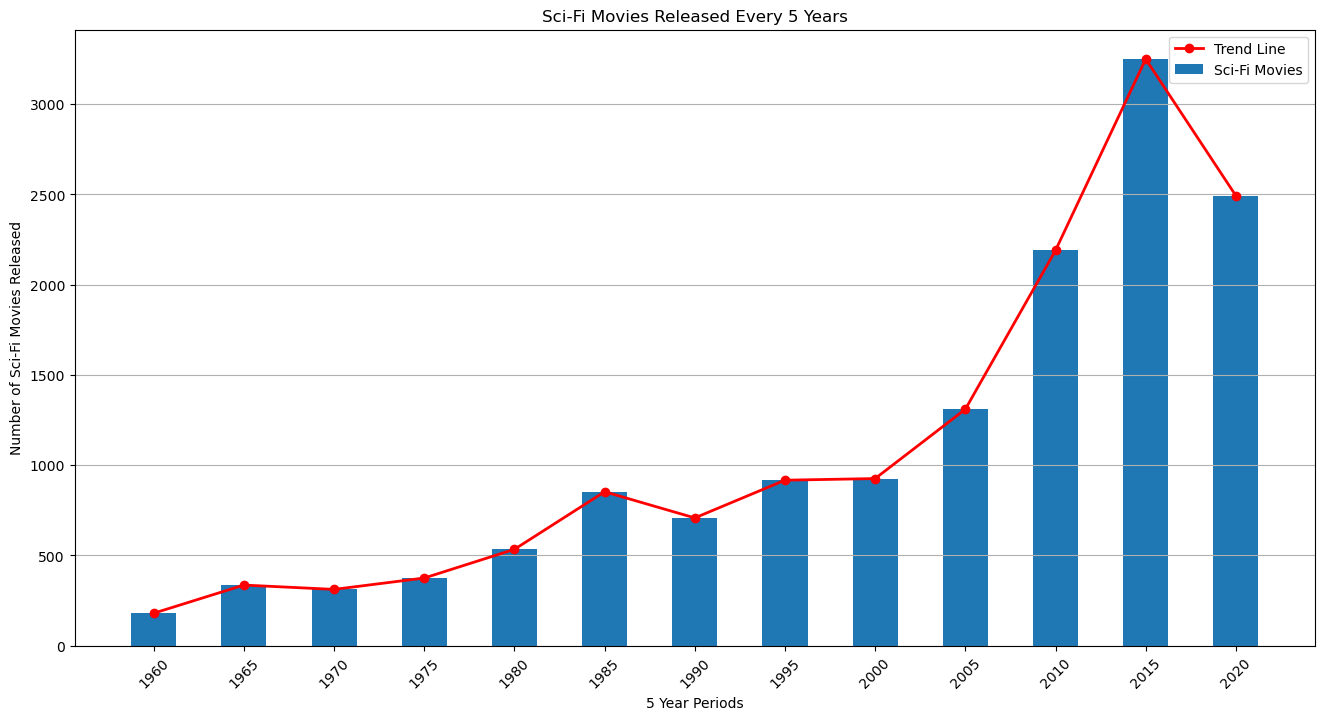

In [69]:
#Converting to datetime
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")

#Create a three year period column to group by
movies["three_year"] = (movies["release_date"].dt.year // 5) * 5

#Search for SciFi movies only and count them
sci_fi = movies[movies["genres"].str.contains("Science Fiction")]
sci_fi_counts = sci_fi.groupby("three_year").size()

#Plotting the visual
plt.figure(figsize=(16,8))

#reating the bar chart and line charts
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=2.5, label="Sci-Fi Movies")
plt.plot(sci_fi_counts.index, sci_fi_counts.values, color="red", marker="o", linewidth=2, label="Trend Line")

#Populating the visual
plt.title("Sci‑Fi Movies Released Every 5 Years")

plt.xlabel("5 Year Periods")
plt.ylabel("Number of Sci‑Fi Movies Released")

plt.xticks(sci_fi_counts.index, rotation=45)

plt.grid(axis="y")
plt.legend()

##Displaying the visual
plt.show()

**Impact on the number of Science Fiction films**

The below graph further highlights the mentioned earlier overlaps, but it still struggles to show any meaningful movement between the two.
It faintly seems like there could be some kind of a correlation bewteen the two, so a correlation analysis using several time-lag series was done (results shown below the graph). The results show a very weak, positive correlation between the number of space missions and Sci-Fi movie output 1-4 years later. Taking a closer look at the lag year of interest (shown in Space Missions vs Sci-Fi Movies) we can see that there is no upward diagonal pattern in the scatterplot, again indicating a lack of any correlation. The number of Sci-Fi movies has generally stayed within the same output range throught the years with only a few outliers, which are most likely due to the genre boom during the 2010s.

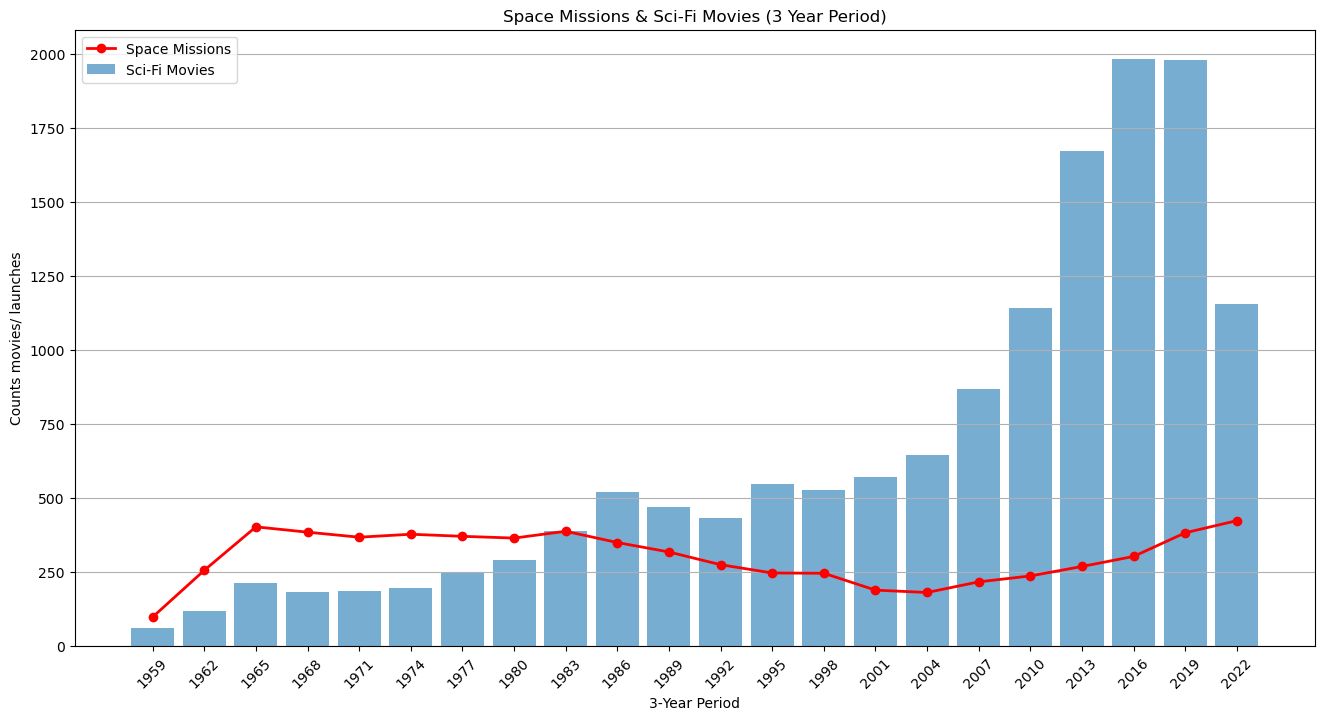

In [85]:
#Converting to datetime
space_missions["date"] = pd.to_datetime(space_missions["date"])

#Creates a three year period column to group and filter by
space_missions["three_year"] = (space_missions["date"].dt.year // 3) * 3

#Counts the missions per 3 years
missions_3yr = space_missions.groupby("three_year").size()

#Create a 3‑year period column for movies
movies["three_year"] = (movies["release_date"].dt.year // 3) * 3

# Filters scifi movies and groups the,
sci_fi = movies[movies["genres"].str.contains("Science Fiction")]
sci_fi_counts = sci_fi.groupby("three_year").size()

#Creating the figure
plt.figure(figsize=(16,8))

#Visualizing SciFi movies as bars and the missions as a linechart
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=2.5, label="Sci‑Fi Movies", alpha=0.6)
plt.plot(missions_3yr.index, missions_3yr.values, color="red", marker="o", linewidth=2, label="Space Missions")

#Populating the visuals
plt.title("Space Missions & Sci‑Fi Movies (3 Year Period)")
plt.xlabel("3‑Year Period")
plt.ylabel("Counts movies/ launches")

plt.xticks(sorted(set(list(missions_3yr.index) + list(sci_fi_counts.index))), rotation=45)
plt.grid(axis="y")
plt.legend()

#Visualizing the graph
plt.show()

In [93]:
#Converting to datetime
space_missions["year"] = pd.to_datetime(space_missions["date"], dayfirst=True).dt.year
movies["year"] = pd.to_datetime(movies["release_date"]).dt.year

#Creates a sci-fi film subset and then an yearly count(s) for missions and sci-fi movies
sci_fi = movies[movies["genres"].str.contains("Science Fiction", na=False)]
missions_year = space_missions.groupby("year").size()
sci_fi_year = sci_fi.groupby("year").size()

#Shifting the scifi movie values (creating lag series) 
missions_lag1 = missions_year.shift(-1)
missions_lag2 = missions_year.shift(-2)
missions_lag3 = missions_year.shift(-3)
missions_lag4 = missions_year.shift(-4)

#Calculating the correlation for each lag
corr_0 = missions_year.corr(sci_fi_year)
corr_1 = missions_lag1.corr(sci_fi_year)
corr_2 = missions_lag2.corr(sci_fi_year)
corr_3 = missions_lag3.corr(sci_fi_year)
corr_4 = missions_lag4.corr(sci_fi_year)

#Print results
print("Analysis Results:\n")
print("Lag 0:", corr_0) #Same year
print("Lag 1:", corr_1) #1 year after
print("Lag 2:", corr_2) #2 years after
print("Lag 3:", corr_3) #3 years after
print("Lag 4:", corr_4) #4 years after

Analysis Results:

Lag 0: 0.11229915548084092
Lag 1: 0.16427629143073993
Lag 2: 0.17411974926398344
Lag 3: 0.17712171115874614
Lag 4: 0.19523324784366633


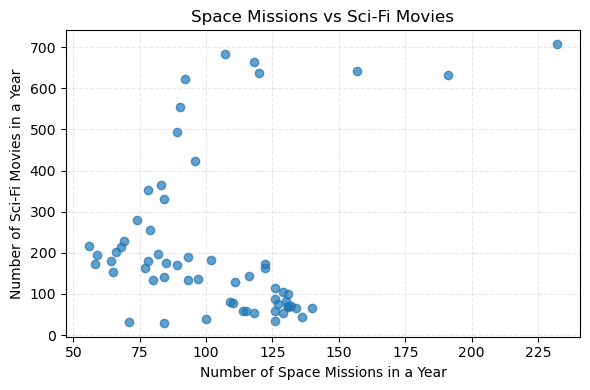

In [99]:
#Scatterplot visual, based on the lag analysis for lag 2
#Chosing the lag I want to visualize
lag = 2

#Alligns mission years and scifi years, keeping the lag
missions_lag = missions_year.shift(-lag)

#Alligns the series
aligned = pd.concat([missions_lag, sci_fi_year], axis=1)
aligned.columns = ["missions_lag", "sci_fi"]

#Builds the scatterplot
plt.figure(figsize=(6,4))
plt.scatter(aligned["missions_lag"], aligned["sci_fi"], alpha=0.7)

#Populates the axis and grid
plt.title(f"Space Missions vs Sci-Fi Movies")
plt.xlabel("Number of Space Missions in a Year")
plt.ylabel(f"Number of Sci-Fi Movies in a Year")

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

#Displays the visual
plt.show()

**Impact on audience's interest**
Include python code and discuss what my observations are; how do I interpret this; does it support or contradict H0

**Conclusion**
Summarize what you did and what the key findings are; grounds for future work or how things can be done better/ differently?

**Reference List**